# Statistical learning example

This notebook demonstrates how to train an LLM on a simple task. As an example we use the statistical learning stimuli in Durrant et al. (2011) 

To explore the effect of sleep on statistical learning, Durrant et al. (2011) constructed two types of sequence, both made up of regular tones at differing frequencies. One type had a structure in which the preceding two tones determined the next, except for a few transitions which were random to avoid repetition. The other type was the reverse – most transitions were random. After listening to a structured sequence, participants were tested on their ability distinguish short structured and unstructured sequences. Delayed recall was then tested, after a night’s sleep for one group, and after a waking rest for the other. Durrant et al. (2011) found that sleep improved performance more than waking rest, suggesting systems consolidation promotes statistical learning.

Here, we generate a set of sequences based on the transition structure in Durrant et al. (2011). We  write these to a file and train the model on the contents. Then we inspect the attention.

## Build training data

Create sequences according to the Durrant et al. (2011) transition structure, and save them.

In [1]:
from pathlib import Path
import os

from llm_psychology.data.statistical_learning import (
    generate_sequence,
    make_attention_probe,
    make_corpus,
    transition_probability_matrix,
)
from llm_psychology.train.tokenizers import make_character_tokenizer
from llm_psychology.train.trainer import train_causal_lm

work_dir = Path("../outputs/tutorial_statistical_learning")
work_dir.mkdir(parents=True, exist_ok=True)

train_path = make_corpus(
    work_dir / "durrant_train_chars.txt",
    num_sequences=int(os.environ.get("DURRANT_TRAIN_SEQUENCES", "10000")),
    length=52,
    error_rate=0.1,
    seed=1,
    separator="",
)
val_path = make_corpus(
    work_dir / "durrant_val_chars.txt",
    num_sequences=int(os.environ.get("DURRANT_VAL_SEQUENCES", "1000")),
    length=52,
    error_rate=0.1,
    seed=2,
    separator="",
)
char_tokenizer = make_character_tokenizer(["1", "2", "3", "4", "5"])

print(train_path)
print(val_path)
print(train_path.read_text().splitlines()[0])
print(char_tokenizer.tokenize("4521553544"))

../outputs/tutorial_statistical_learning/durrant_train_chars.txt
../outputs/tutorial_statistical_learning/durrant_val_chars.txt
2512331321553544345254434521553544345215535443452155
['4', '5', '2', '1', '5', '5', '3', '5', '4', '4']


Let's inspect the transition structure. With `error_rate=0.1`, the dominant transition should still match the Durrant rule most of the time:

In [2]:
example_sequence = generate_sequence(length=20, error_rate=0.0, rng=__import__("random").Random(1))
print("Noise-free example:", "".join(example_sequence))

sequences = train_path.read_text().splitlines()[:500]
matrix, contexts, token_labels = transition_probability_matrix(sequences)
for context, row in zip(contexts[:10], matrix[:10]):
    best = token_labels[row.argmax()]
    print(f"{context} -> {best}  probs={row.round(2).tolist()}")

Noise-free example: 25123313224251233132
1,1 -> 4  probs=[0.02, 0.02, 0.02, 0.92, 0.02]
1,2 -> 3  probs=[0.02, 0.03, 0.91, 0.02, 0.03]
1,3 -> 2  probs=[0.02, 0.9, 0.02, 0.03, 0.03]
1,4 -> 1  probs=[0.91, 0.02, 0.02, 0.03, 0.02]
1,5 -> 5  probs=[0.02, 0.02, 0.02, 0.02, 0.92]
2,1 -> 5  probs=[0.01, 0.02, 0.01, 0.02, 0.93]
2,2 -> 4  probs=[0.02, 0.02, 0.01, 0.92, 0.02]
2,3 -> 3  probs=[0.02, 0.02, 0.91, 0.02, 0.03]
2,4 -> 2  probs=[0.02, 0.92, 0.02, 0.02, 0.02]
2,5 -> 1  probs=[0.92, 0.02, 0.02, 0.03, 0.01]


## Train a mini GPT-2 model on the task

In [3]:
model, tokenizer, metrics = train_causal_lm(
    model_name="gpt2",
    tokenizer=char_tokenizer,
    train_path=str(train_path),
    eval_path=str(val_path),
    output_dir=str(work_dir / "model"),
    from_scratch=True,
    n_layer=int(os.environ.get("DURRANT_N_LAYER", "4")),
    n_head=int(os.environ.get("DURRANT_N_HEAD", "4")),
    n_embd=int(os.environ.get("DURRANT_N_EMBD", "256")),
    max_steps=int(os.environ.get("DURRANT_MAX_STEPS", "3000")),
    block_size=128,
    per_device_train_batch_size=int(os.environ.get("DURRANT_BATCH_SIZE", "16")),
    per_device_eval_batch_size=int(os.environ.get("DURRANT_EVAL_BATCH_SIZE", "16")),
    learning_rate=2e-4,
    logging_steps=100,
    eval_steps=500,
)
metrics

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

...

Step,Training Loss,Validation Loss
500,0.551200,0.514425
1000,0.498200,0.500431
1500,0.492400,0.499548
2000,0.495500,0.495507
2500,0.485800,0.493677
3000,0.486400,0.493404


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.49340420961380005,
 'eval_runtime': 0.2813,
 'eval_samples_per_second': 1443.242,
 'eval_steps_per_second': 92.424,
 'epoch': 11.811023622047244}

## Check a next-item prediction

Only the final two prompt items determine the target. The score table gives a quick behavioural check before looking at attention.

In [4]:
import torch

probe = make_attention_probe(context_length=20, error_rate=0.0, seed=11, separator="")
prompt = probe["prompt"]
target = probe["target"]
print("Prompt:", prompt)
print("Expected next item:", target)
print("Relevant prompt positions:", probe["relevant_item_positions"])
print("Prompt tokens:", tokenizer.tokenize(prompt))

inputs = tokenizer(prompt, return_tensors="pt")
device = next(model.parameters()).device
inputs = inputs.to(device)
model.eval()
with torch.no_grad():
    logits = model(**inputs).logits[0, -1]

candidate_scores = {}
for token in ["1", "2", "3", "4", "5"]:
    token_ids = tokenizer(token, add_special_tokens=False).input_ids
    candidate_scores[token] = float(logits[token_ids[-1]].detach().cpu())

sorted(candidate_scores.items(), key=lambda item: item[1], reverse=True)

Prompt: 45215535443452155354
Expected next item: 4
Relevant prompt positions: [18, 19]
Prompt tokens: ['4', '5', '2', '1', '5', '5', '3', '5', '4', '4', '3', '4', '5', '2', '1', '5', '5', '3', '5', '4']


[('4', 5.052957057952881),
 ('3', 1.5949852466583252),
 ('2', 1.5778768062591553),
 ('5', 1.5302722454071045),
 ('1', 1.5149846076965332)]

## Inspect averaged attention

This samples many prompts from the same statistical-learning distribution and averages the attention maps.

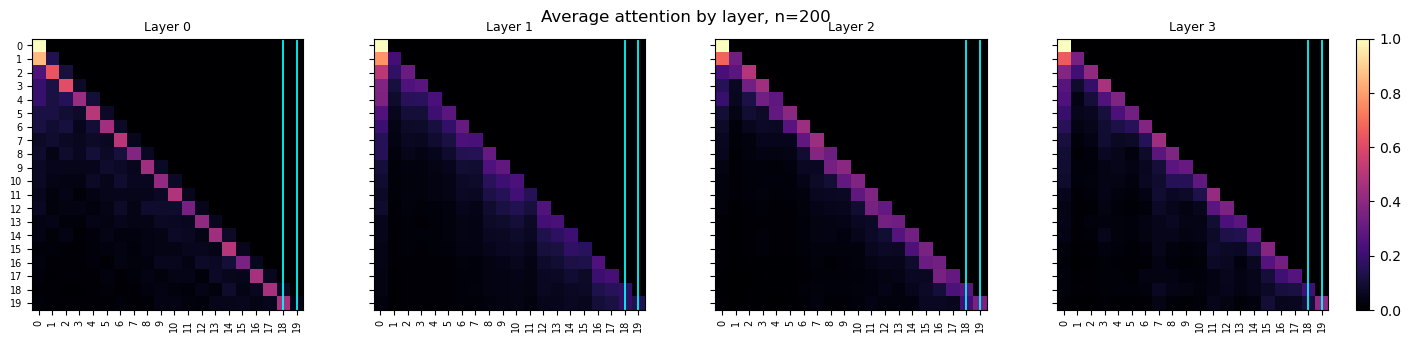

../outputs/tutorial_statistical_learning/attention/average_attention_by_layer_mean_heads.png


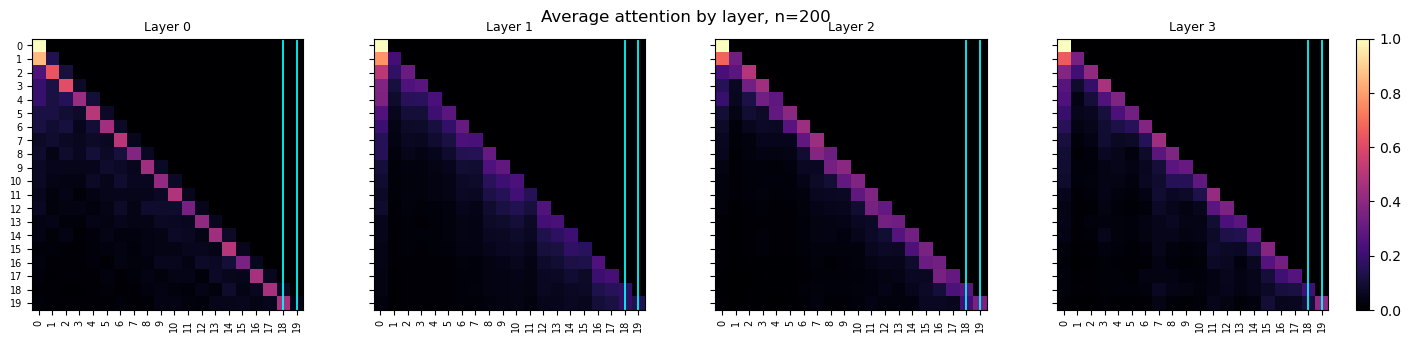

In [5]:
from IPython.display import display

from llm_psychology.reps.extractor import extract_attention_weights
from llm_psychology.viz.attention import plot_attention_by_layer

if hasattr(model.config, "_attn_implementation"):
    model.config._attn_implementation = "eager"

attention_dir = work_dir / "attention"
attention_dir.mkdir(parents=True, exist_ok=True)

attention_sample_count = int(os.environ.get("DURRANT_ATTENTION_SAMPLES", "200"))
attention_sample_batch_size = int(os.environ.get("DURRANT_ATTENTION_BATCH_SIZE", "32"))
attention_sample_error_rate = float(os.environ.get("DURRANT_ATTENTION_ERROR_RATE", "0.1"))
attention_sample_seed = int(os.environ.get("DURRANT_ATTENTION_SEED", "1000"))
if attention_sample_count < 1:
    raise ValueError("DURRANT_ATTENTION_SAMPLES must be at least 1.")

sampled_probes = [
    make_attention_probe(
        context_length=20,
        error_rate=attention_sample_error_rate,
        seed=attention_sample_seed + sample_idx,
        separator="",
    )
    for sample_idx in range(attention_sample_count)
]
sampled_prompts = [item["prompt"] for item in sampled_probes]
relevant_positions = sampled_probes[0]["relevant_item_positions"]

attention_sum = None
for start in range(0, len(sampled_prompts), attention_sample_batch_size):
    batch_prompts = sampled_prompts[start : start + attention_sample_batch_size]
    batch_attn, _, _ = extract_attention_weights(model, tokenizer, batch_prompts)
    batch_array = batch_attn.detach().cpu().numpy()
    attention_sum = batch_array.sum(axis=0) if attention_sum is None else attention_sum + batch_array.sum(axis=0)

average_attention = (attention_sum / len(sampled_prompts))[None, ...]
position_labels = [str(position) for position in range(average_attention.shape[-1])]

fig_avg_layers = plot_attention_by_layer(
    average_attention,
    position_labels,
    head=None,
    relevant_positions=relevant_positions,
    title=f"Average attention by layer, n={len(sampled_prompts)}",
)
figure_path = attention_dir / "average_attention_by_layer_mean_heads.png"
fig_avg_layers.savefig(figure_path, dpi=180, bbox_inches="tight")
display(fig_avg_layers)
print(figure_path)
